# EPLB Benchmark Analysis

Compare EPLB configurations across collected benchmark runs.

**Prerequisites:** Collect results with `just eplb-collect <run-name>` before running this notebook.
Each run lives in `benchmarks/eplb/<run-name>/` and contains `config.env`, `prometheus.json`, and `expert-load/` dumps.

See `benchmarks/eplb/README.md` for the full benchmark plan and execution steps.

In [7]:
%load_ext autoreload
%autoreload 2

from eplb_analysis import (
    load_run,
    load_runs,
    load_all_runs,
    list_runs,
    metrics_comparison_table,
    stage_metrics_table,
    balancedness_comparison_table,
    plot_latency_comparison,
    plot_throughput_comparison,
    plot_throughput_timeseries,
    plot_kv_cache_usage,
    plot_balancedness_comparison,
    plot_latency_timeseries,
    plot_phase_time_comparison,
    plot_phase_time_timeseries,
    plot_pareto_frontier,
    plot_throughput_vs_concurrency,
    plot_expert_load_all,
    plot_expert_load_heatmap,
    plot_rank_balance,
    plot_expert_popularity,
    plot_balancedness_over_time,
    plot_rank_balance_at_steps,
    plot_per_rank_latency_heatmap,
    plot_per_rank_latency_spread,
    plot_per_rank_comparison,
    per_rank_stats_table,
    filter_runs,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 30)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Runs

List available runs and load a subset for comparison. Adjust `run_names` to pick the runs you want to analyze.

In [2]:
print("Available runs:")
for name in list_runs():
    print(f"  {name}")

Available runs:
  agg-sync-eplb-v1
  pd-async-eplb-both
  pd-async-eplb-both-p32-d128
  pd-async-eplb-short-re0
  pd-async-eplb-short-re0-v1
  pd-async-eplb-short-re32
  pd-async-eplb-short-re32-d8
  pd-baseline-short
  pd-baseline-short-d8
  pd-baseline-short-v1
  pd-baseline-short-v1-d8
  pd-baseline-short-v2-d8
  pd-baseline-short-v3-d8
  pd-baseline-short-v4-d8
  pd-baseline-stats
  pd-baseline-stats-re0
  pd-sync-eplb-both
  pd-sync-eplb-d8


In [19]:
# Edit this list to select which runs to compare
# run_names = list_runs()  # or e.g. ["pd-no-eplb", "pd-sync-eplb", "pd-async-eplb"]

# run_names = [
#     "pd-async-eplb-short-re0-v1",
#     "pd-baseline-short-v1-d8"
# ]

results_dir = "./load_1800_short"

# selected = filter_runs(name_contains="short", mode="pd", custom=lambda n, r: r.config.num_redundant > 0)
# selected = filter_runs(mode="pd", decode_pods=8, custom=lambda n, r: (r.config.step_interval > 10000 or r.config.eplb_mode in ["async"]) and r.config.num_redundant == 32)
selected = filter_runs(results_dir=results_dir, mode="pd", decode_pods=8, fork="study_v2")
# selected = filter_runs(mode="pd", decode_pods=4, name_excludes="short", custom=lambda n, c: c.num_redundant < 128)
runs = {name: load_run(name, results_dir) for name in selected.keys()}

print(f"Loaded {len(runs)} runs:")
for name, run in runs.items():
    expert_info = ""
    if run.expert_loads:
        n_snaps = sum(e.num_snapshots for e in run.expert_loads.values())
        expert_info = f", {n_snaps} expert snapshots"
    prom_info = "prometheus OK" if run.prometheus else "no prometheus"
    print(f"  {name}: {run.config} | {prom_info}{expert_info}")

Loaded 2 runs:
  pd-async-eplb-short-re0-v1: RunConfig('pd-async-eplb-short-re0-v1', mode=pd, eplb=async, dataset=sharegpt, redundant=0, interval=300, lws=4, decode=1x8, prefill=2x1) | prometheus OK, 267 expert snapshots
  pd-baseline-short-v5-d8: RunConfig('pd-baseline-short-v5-d8', mode=pd, eplb=off, dataset=sharegpt, redundant=32, interval=3000, lws=4, decode=1x8, prefill=2x1) | prometheus OK


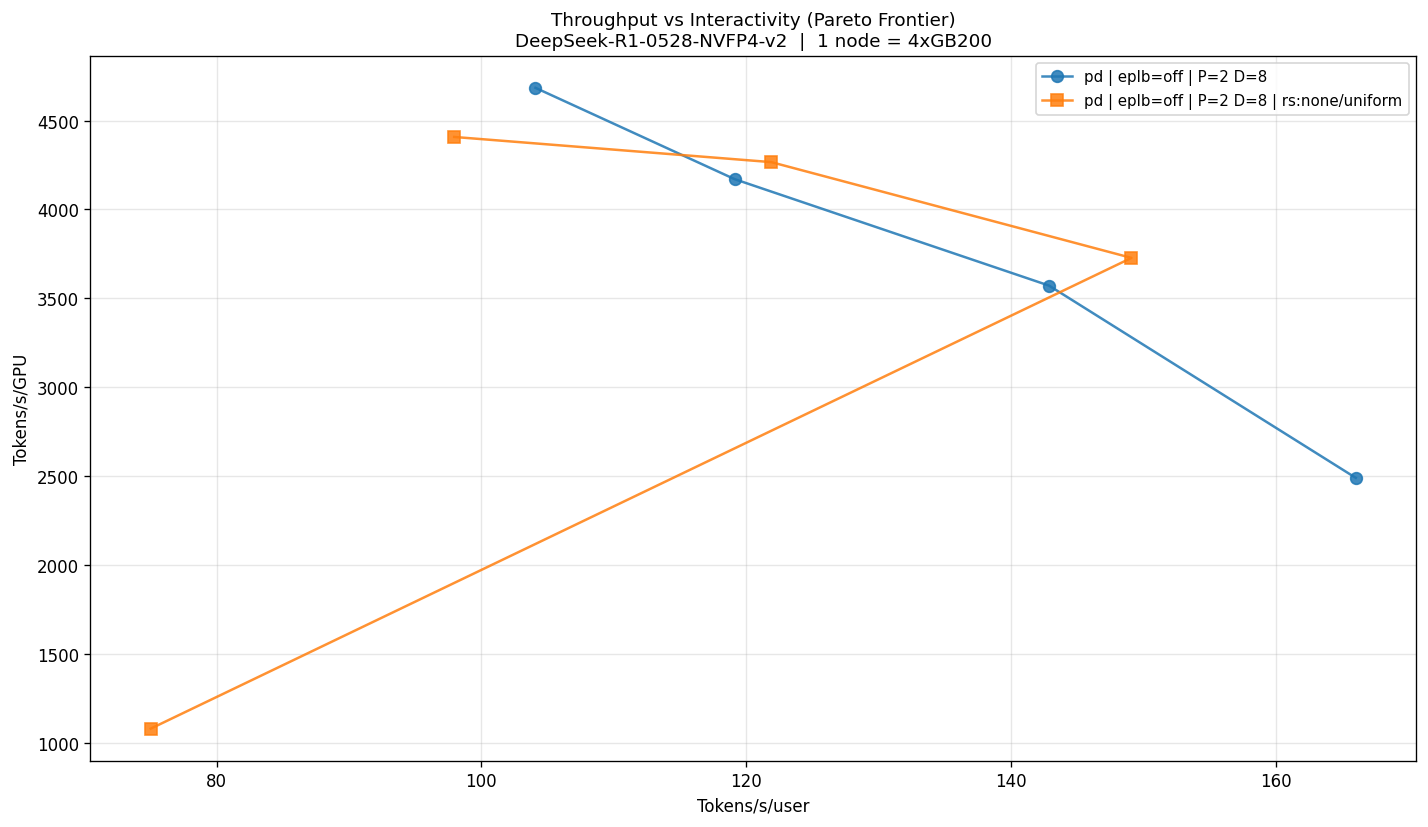

In [13]:
plot_pareto_frontier(runs)

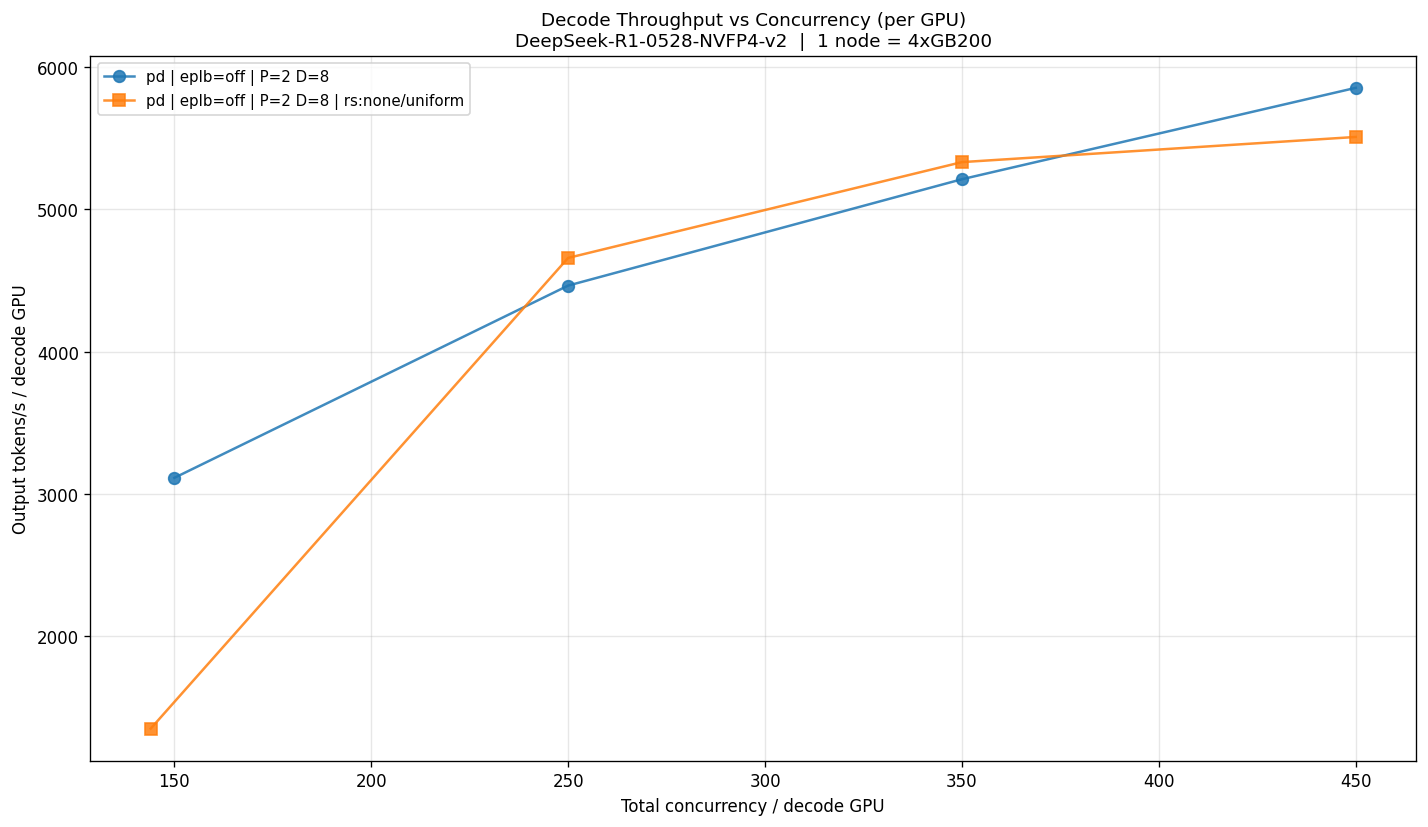

In [14]:
plot_throughput_vs_concurrency(runs)

## 2. Metrics Overview

Summary table of Prometheus metrics across runs. Latencies in milliseconds.

In [5]:
df_metrics = metrics_comparison_table(runs)
df_metrics

,mode,eplb,dataset,decode_redundant,prefill_redundant,interval,lws_size,decode_pods,prefill_pods,prom_duration_m,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,itl_p50_ms,itl_p95_ms,...,queue_p50_ms,queue_p95_ms,queue_p99_ms,prefill_time_p50_ms,prefill_time_p95_ms,prefill_time_p99_ms,decode_time_p50_ms,decode_time_p95_ms,decode_time_p99_ms,gen_tokens_per_sec,prompt_tokens_per_sec,requests_running,requests_waiting,kv_cache_usage,nixl_xfer_p99_ms
run,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
pd-async-eplb-short-re0-v1,pd,async,sharegpt,0,32,300,4,8,2,161.067,429.390,4375.695,9333.627,62.389,91.256,...,162.333,2061.264,7187.390,217.854,1245.683,1498.211,289.340,112844.253,118568.851,146597.228,107594.453,14231.000,27.000,0.175,98.009
pd-baseline-short-d8,pd,off,sharegpt,32,32,3000,4,8,2,160.583,484.034,5642.377,9488.487,59.305,73.604,...,175.153,3407.780,8744.006,289.502,1413.076,1804.580,294.655,103102.686,116620.537,154948.741,179368.112,11962.000,44.000,0.128,96.298


## 3. Latency Comparison

### 3a. TTFT and ITL per concurrency stage

One group of bars per concurrency stage, one bar per run. Shows at which load level
each configuration starts to degrade.

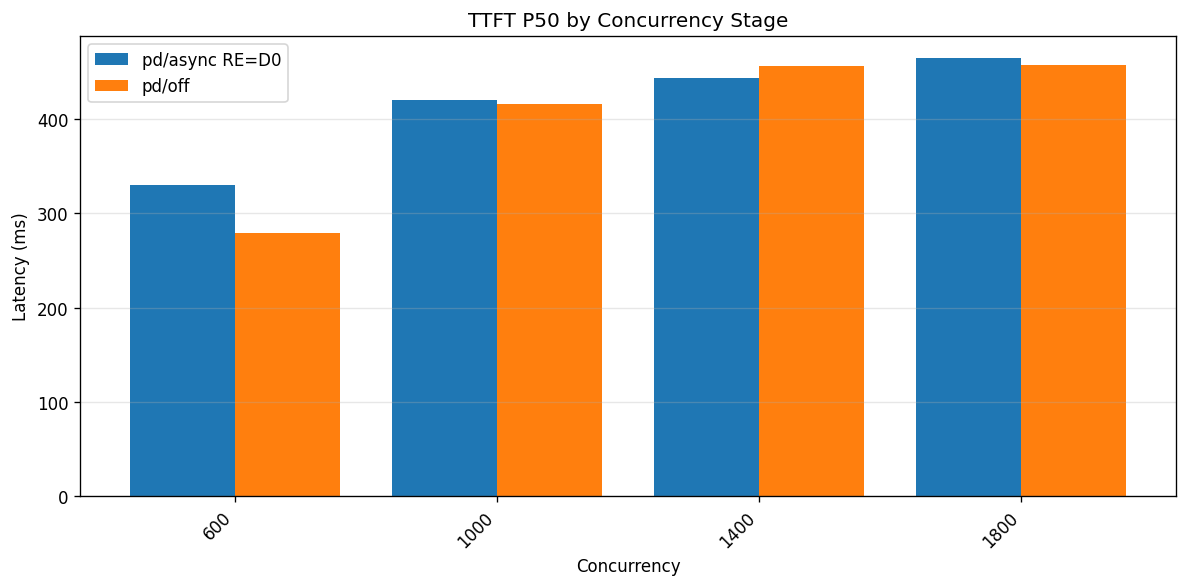

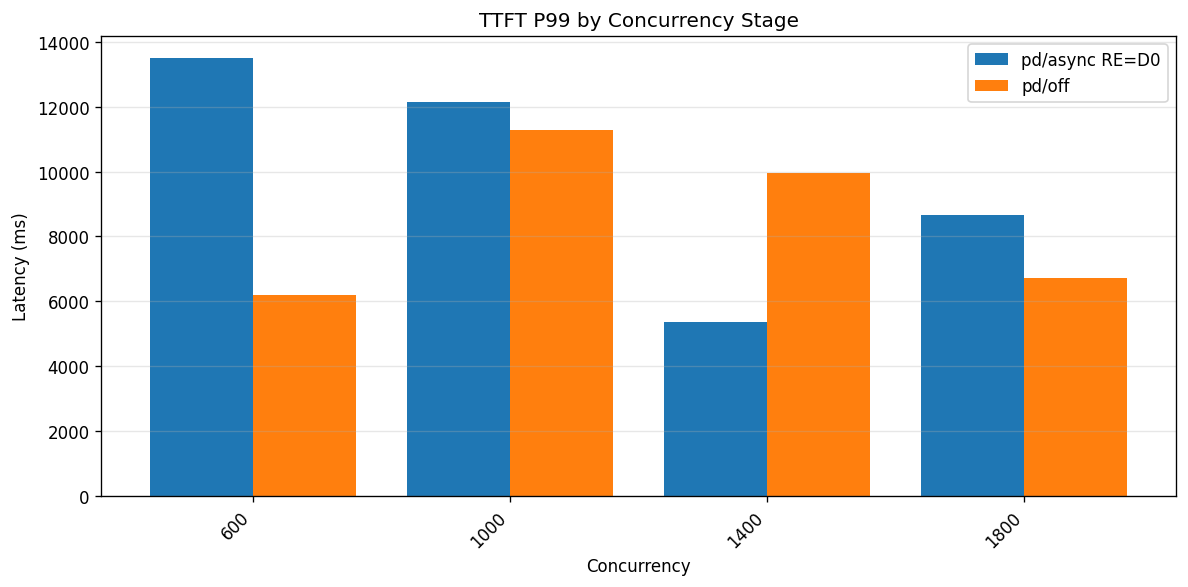

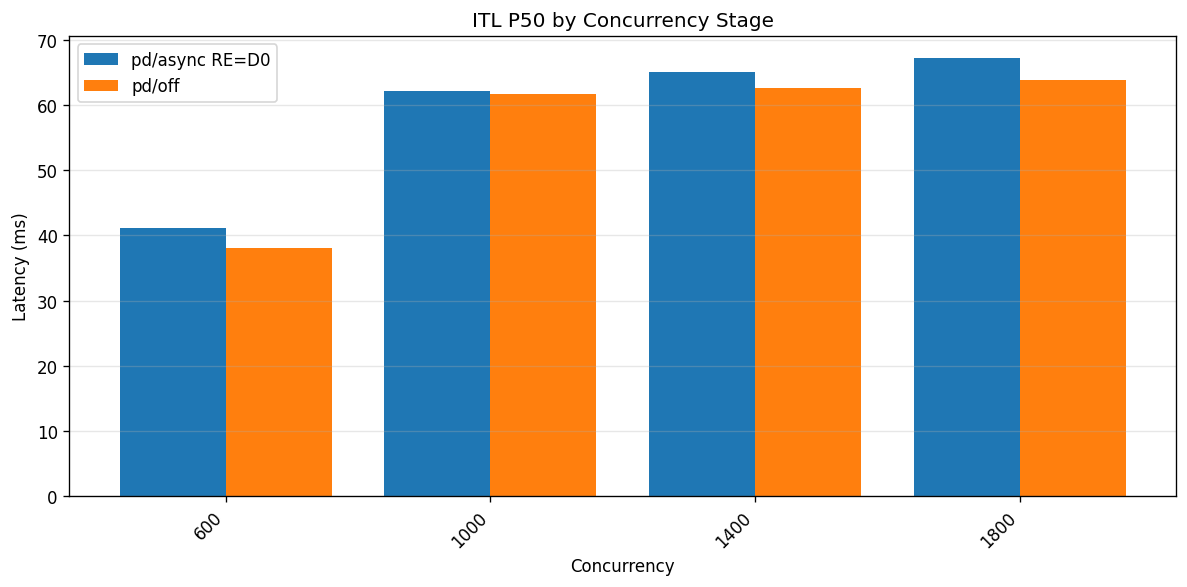

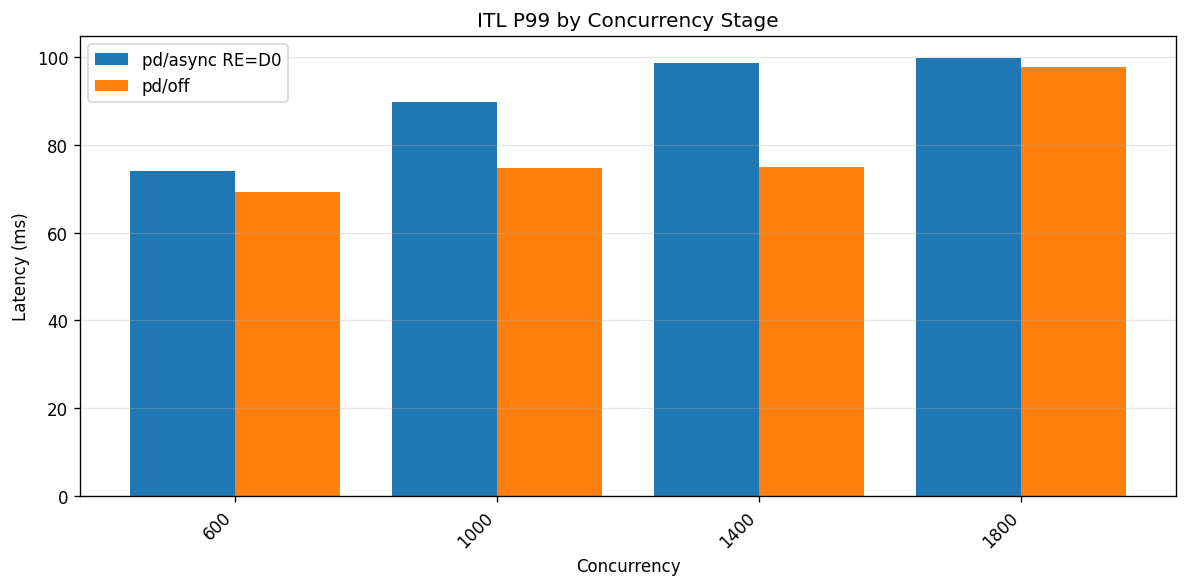

In [29]:
plot_latency_comparison(runs, metric="ttft_p50", title="TTFT P50 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="ttft_p99", title="TTFT P99 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="itl_p50", title="ITL P50 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="itl_p99", title="ITL P99 by Concurrency Stage")
plt.show()

### 3b. Latency time series

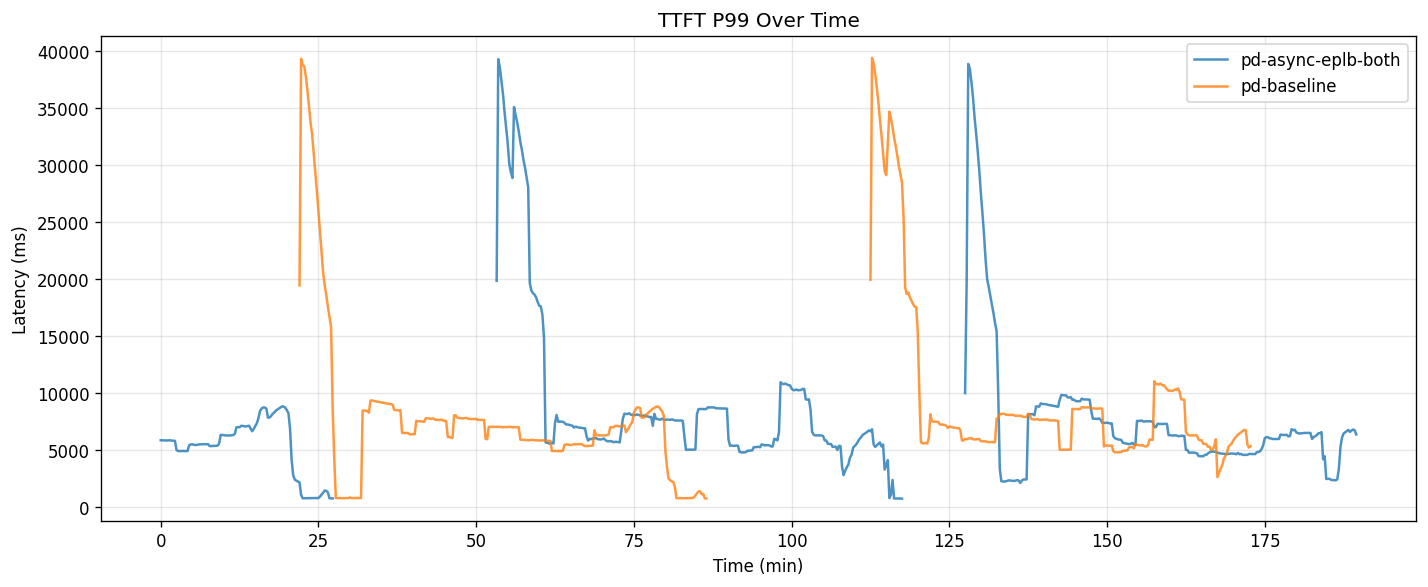

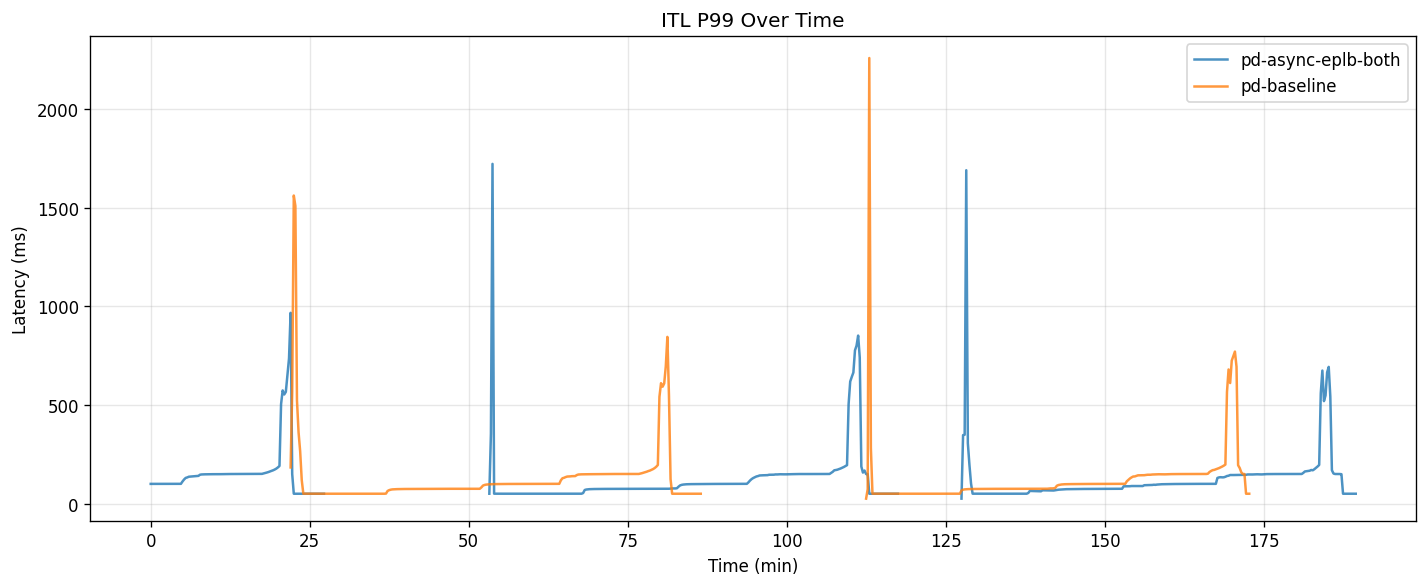

In [32]:
plot_latency_timeseries(runs, "ttft_p99_range", "TTFT P99 Over Time")
plt.show()
plot_latency_timeseries(runs, "itl_p99_range", "ITL P99 Over Time")
plt.show()

### 3c. Phase time breakdown

Where is latency spent? Prefill compute, decode compute, or queue. EPLB primarily affects decode time.

In [ ]:
plot_phase_time_comparison(runs, percentile="p99")
plt.show()
plot_phase_time_comparison(runs, percentile="p50")
plt.show()
plot_phase_time_timeseries(runs)
plt.show()

## 4. Throughput Comparison

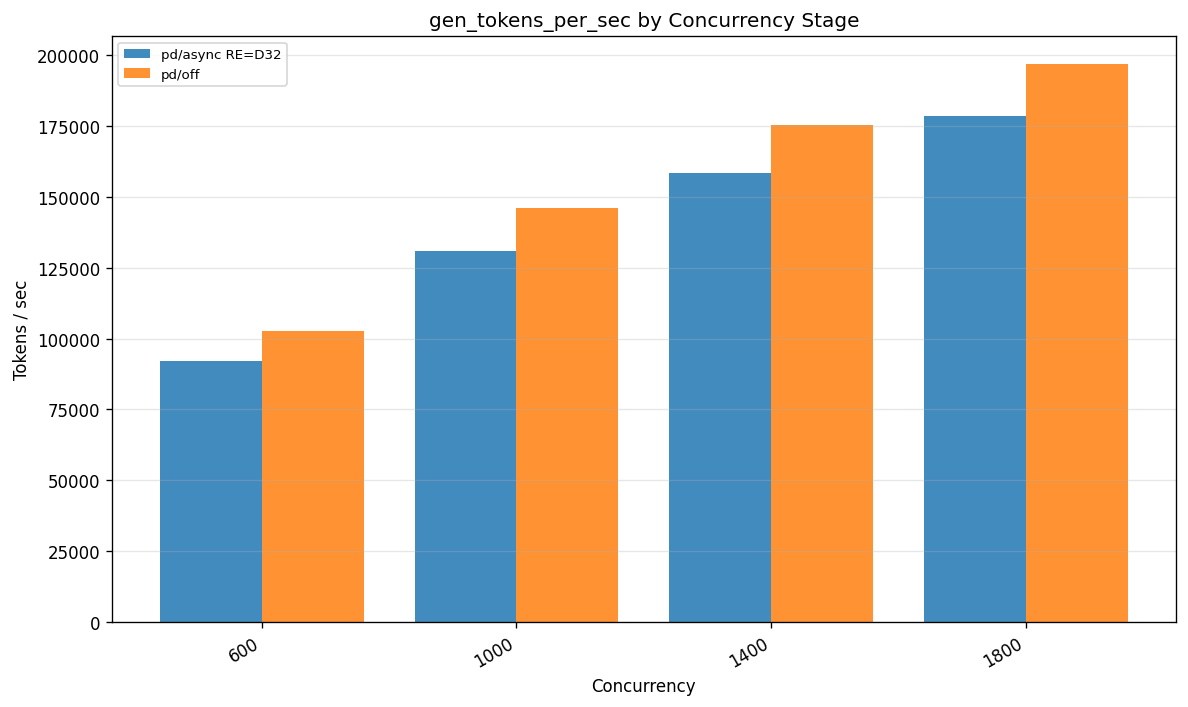

In [68]:
plot_throughput_comparison(runs)
plt.show()
# plot_throughput_timeseries(runs)
# plt.show()

## 4b. Throughput vs Interactivity (Pareto Frontier)

Each point is one concurrency stage. The curve shows the tradeoff: as system throughput
increases (more concurrent users), per-user output speed degrades.

Points on the upper-right frontier are optimal — you can't improve one axis without
sacrificing the other. Annotations show concurrency at each point.

In [41]:
run_names = ["pd-async-eplb-both", "pd-async-eplb-both-p32-d128"]
runs = {name: load_run(name) for name in run_names}

In [ ]:
plot_pareto_frontier(runs)
plt.show()

# for name, run in runs.items():
#     df_stages = stage_metrics_table(run)
#     if df_stages is not None:
#         print(f"\n=== {name}: per-stage metrics ===")
#         display(df_stages)

## 5. KV Cache Usage

Important for `num_redundant_experts` sweeps -- more redundant experts consume memory that would otherwise hold KV cache.

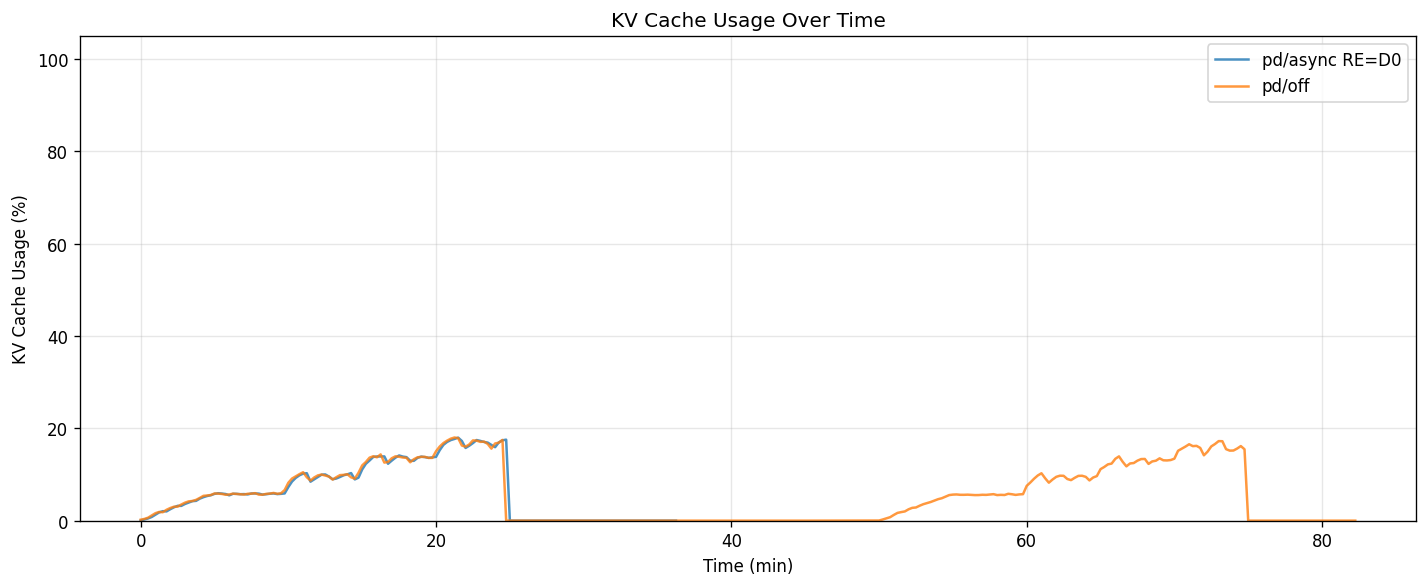

In [30]:
plot_kv_cache_usage(runs)
plt.show()

## 6. Expert Load Balancedness

### 6a. Cross-run balancedness comparison

In [13]:
df_bal = balancedness_comparison_table(runs)
if not df_bal.empty:
    display(df_bal)
else:
    print("No expert load data available.")

,eplb,snapshots,final_mean_bal,final_worst_bal,final_worst_layer,avg_mean_bal,avg_worst_bal
run,,,,,,,
pd/sync RE=32 *no rebalance(decode+prefill),sync,54,0.715,0.468,21,0.683,0.475
pd/sync RE=0 *no rebalance(decode+prefill),sync,55,0.758,0.515,21,0.724,0.504


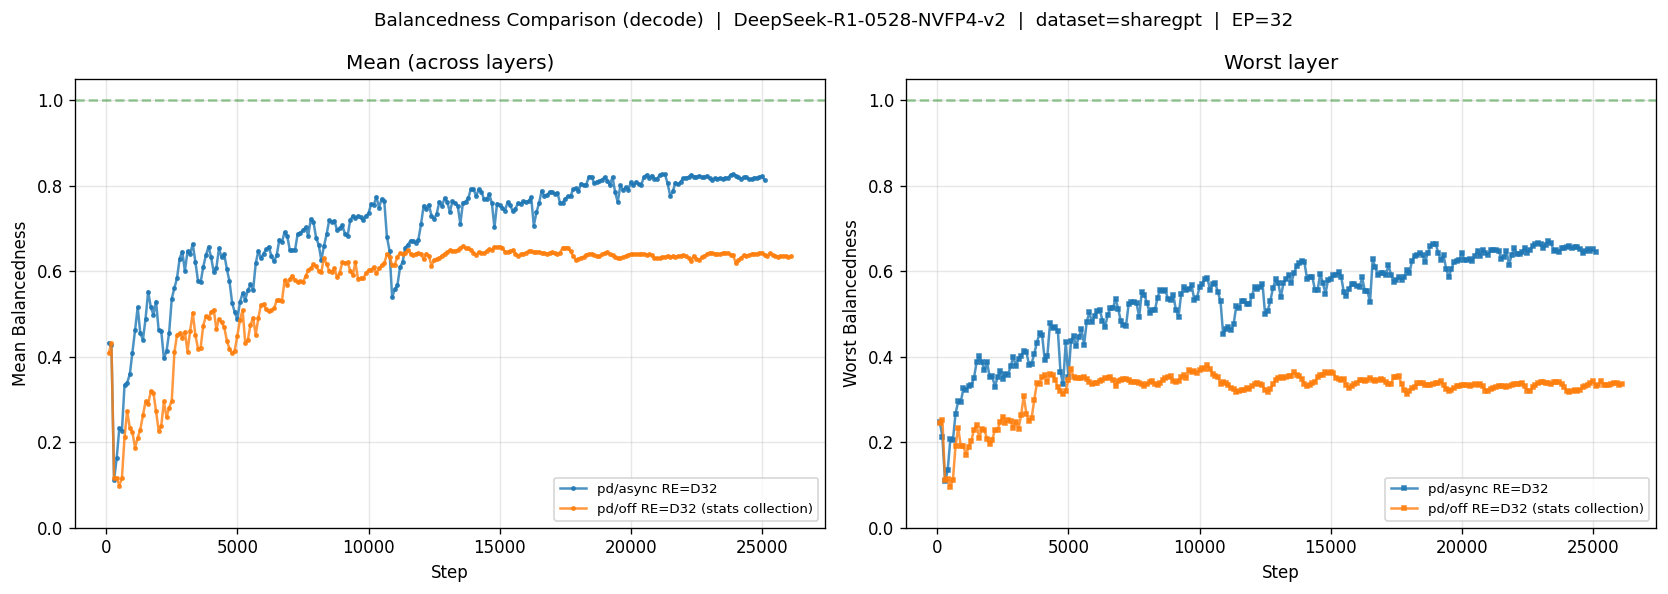

In [26]:
plot_balancedness_comparison(runs, max_step="auto", role="decode", show_heatmaps=False)
plt.show()

In [ ]:
for run in runs.values():
    plot_rank_balance_at_steps(run, steps=[10000], role="decode")

### 6c. Per-Rank Latency Analysis

Compare how latency distributes across EP ranks **at each concurrency stage**. If EPLB leaves certain ranks overloaded, per-rank metrics will show high spread (max/mean ratio ≫ 1).

In [4]:
df_rank = per_rank_stats_table(runs)
if not df_rank.empty:
    display(df_rank.round(2))
else:
    print("No per-rank range data found — check that per_rank_*_range keys exist in prometheus.json")

mean     std        min  \
run             concurrency metric                                             
pd/async RE=D32 600         itl_p50                41.900   0.040     41.810   
                            itl_p99                74.450   0.040     74.380   
                            decode_time_p50     80379.460 894.030  78883.610   
                            decode_time_p99    119207.590  17.880 119177.670   
                            gen_tokens_per_sec   2671.000  77.600   2497.830   
...                                                   ...     ...        ...   
pd/sync RE=D32  1800        itl_p50                63.610   0.020     63.570   
                            itl_p99                98.390   0.060     98.280   
                            decode_time_p50     87772.860 282.200  87119.900   
                            decode_time_p99    119355.460   5.640 119342.400   
                            gen_tokens_per_sec   5403.880 109.360   5144.550   

                                                      max  max/mean  min_rank  \
run             concurrency metric                                              
pd/async RE=D32 600         itl_p50                41.960     1.000         5   
                            itl_p99                74.540     1.000         0   
                            decode_time_p50     82346.240     1.020        18   
                            decode_time_p99    119246.920     1.000        18   
                            gen_tokens_per_sec   2809.750     1.050        15   
...                                                   ...       ...       ...   
pd/sync RE=D32  1800        itl_p50                63.660     1.000        21   
                            itl_p99                98.500     1.000         8   
                            decode_time_p50     88382.750     1.010        31   
                            decode_time_p99    119367.650     1.000        31   
                            gen_tokens_per_sec   5561.670     1.030         3   

                                                max_rank  
run             concurrency metric                        
pd/async RE=D32 600         itl_p50                   22  
                            itl_p99                    5  
                            decode_time_p50           16  
                            decode_time_p99           16  
                            gen_tokens_per_sec        24  
...                                                  ...  
pd/sync RE=D32  1800        itl_p50                    7  
                            itl_p99                   29  
                            decode_time_p50           21  
                            decode_time_p99           21  
                            gen_tokens_per_sec        11  

[120 rows x 7 columns]

In [ ]:
plot_per_rank_latency_spread(runs, metric="itl_p99", title="Per-Rank ITL P99 — min/median/max across ranks by stage")
plt.show()
plot_per_rank_latency_spread(runs, metric="decode_time_p50", title="Per-Rank Decode Time P50 — spread by stage")
plt.show()

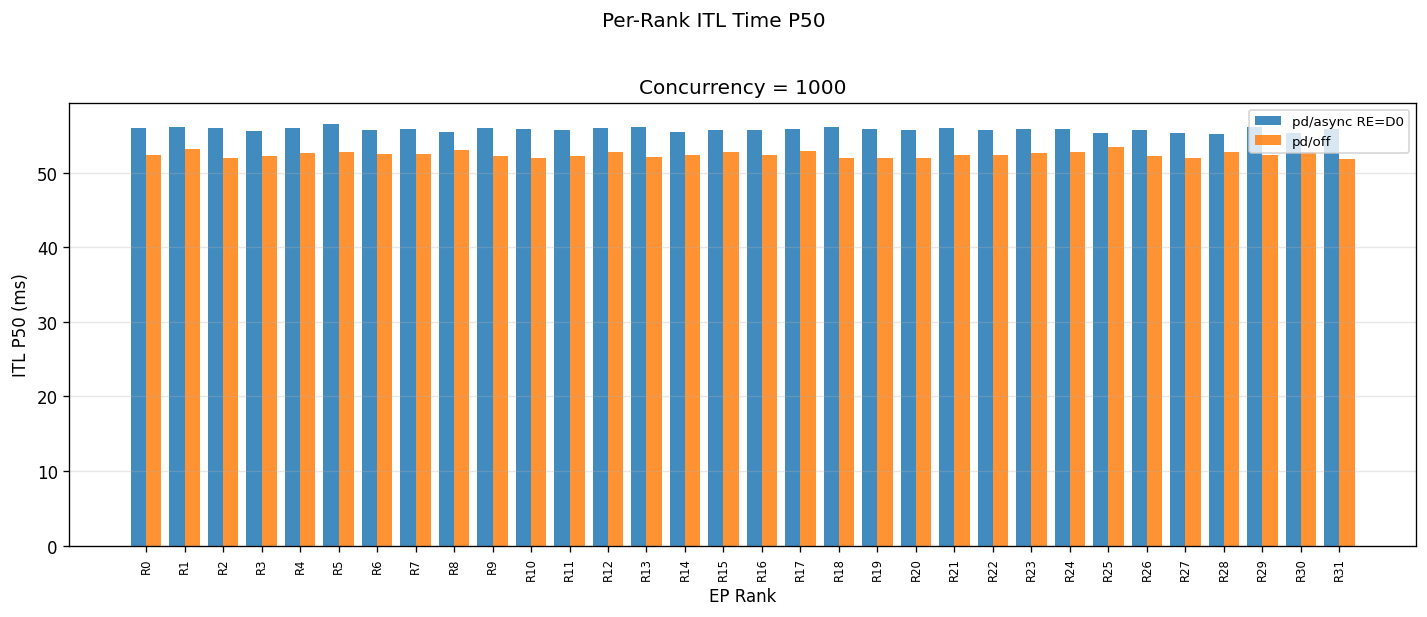

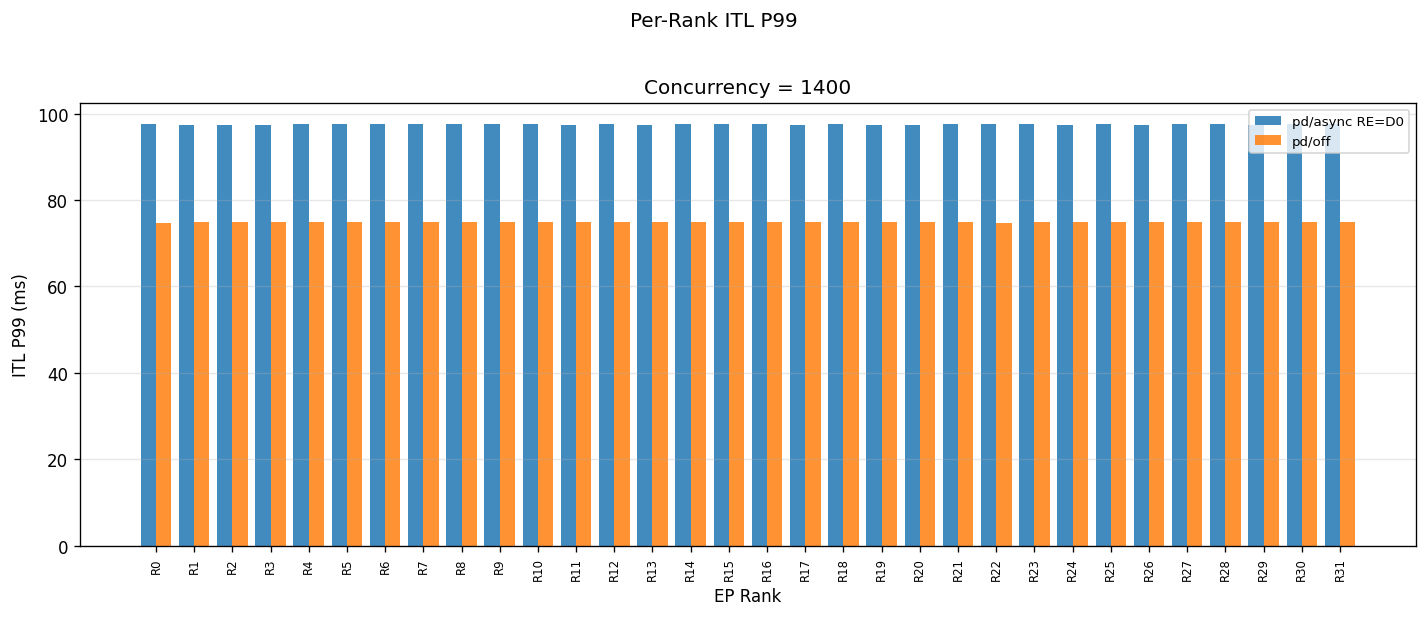

In [31]:
plot_per_rank_comparison(runs, metric="itl_p50", title="Per-Rank ITL Time P50", stage=1)
plt.show()
plot_per_rank_comparison(runs, metric="itl_p99", title="Per-Rank ITL P99", stage=2)
plt.show()

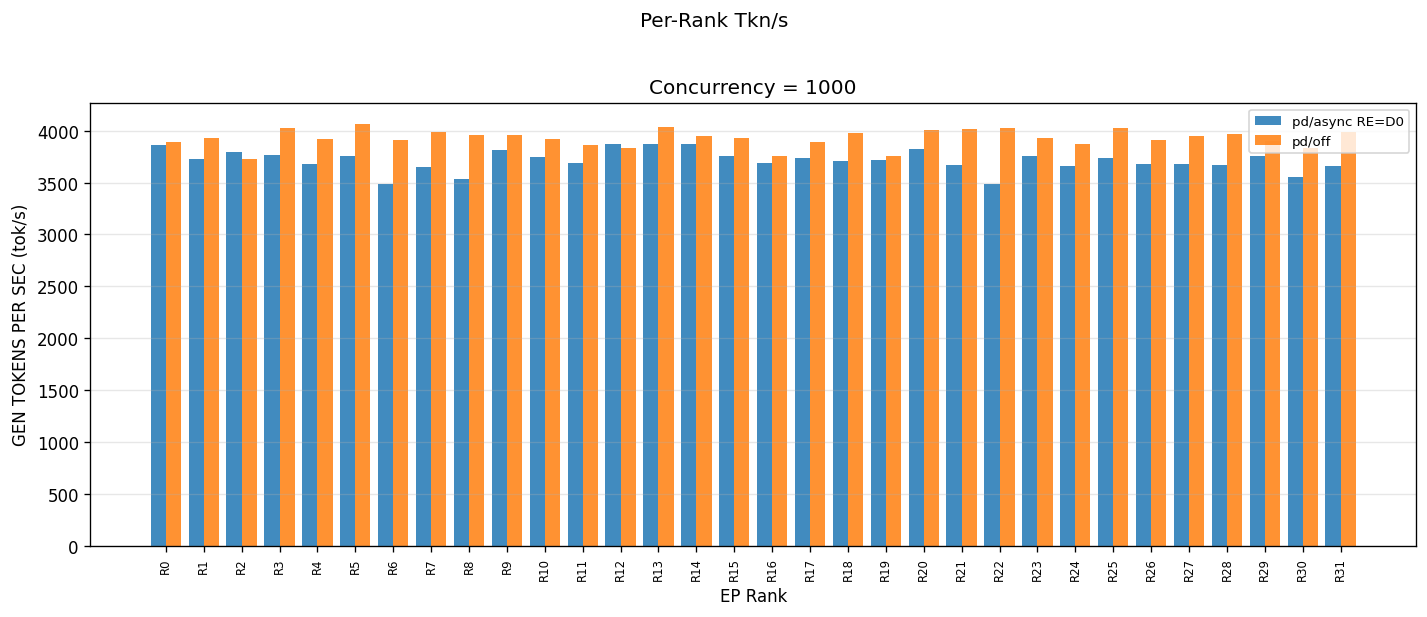

In [13]:
plot_per_rank_comparison(runs, metric="gen_tokens_per_sec", title="Per-Rank Tkn/s", stage=1)
plt.show()

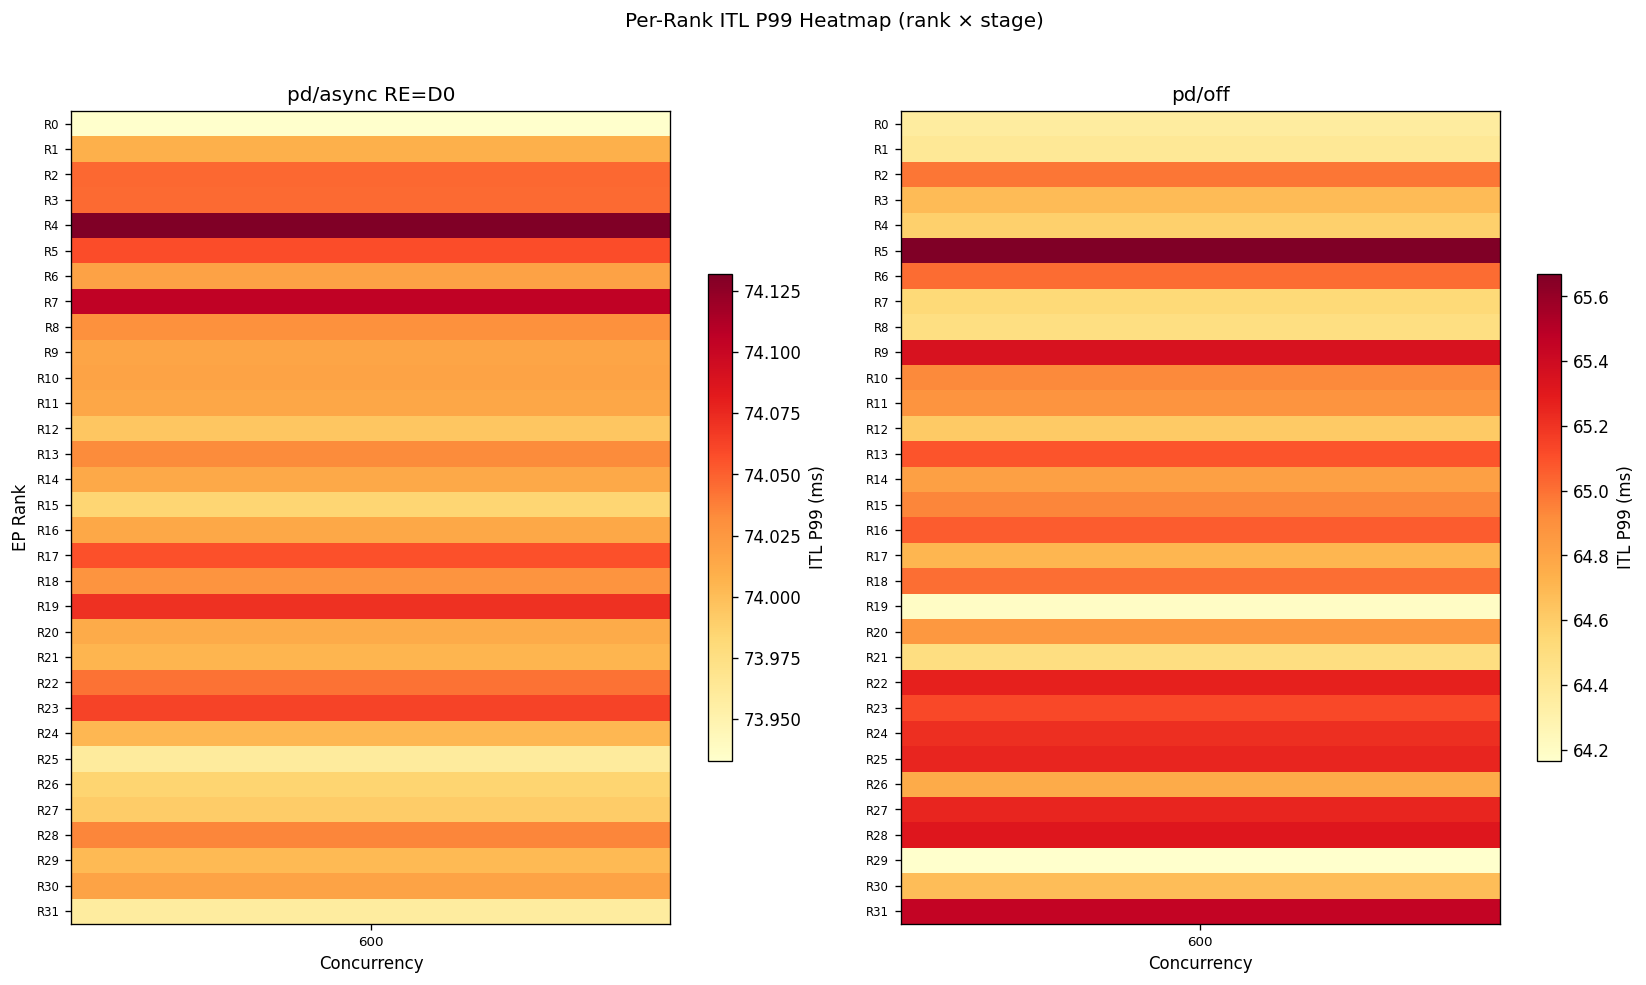

In [32]:
plot_per_rank_latency_heatmap(runs, metric="itl_p99", title="Per-Rank ITL P99 Heatmap (rank × stage)", stage=0)
plt.show()

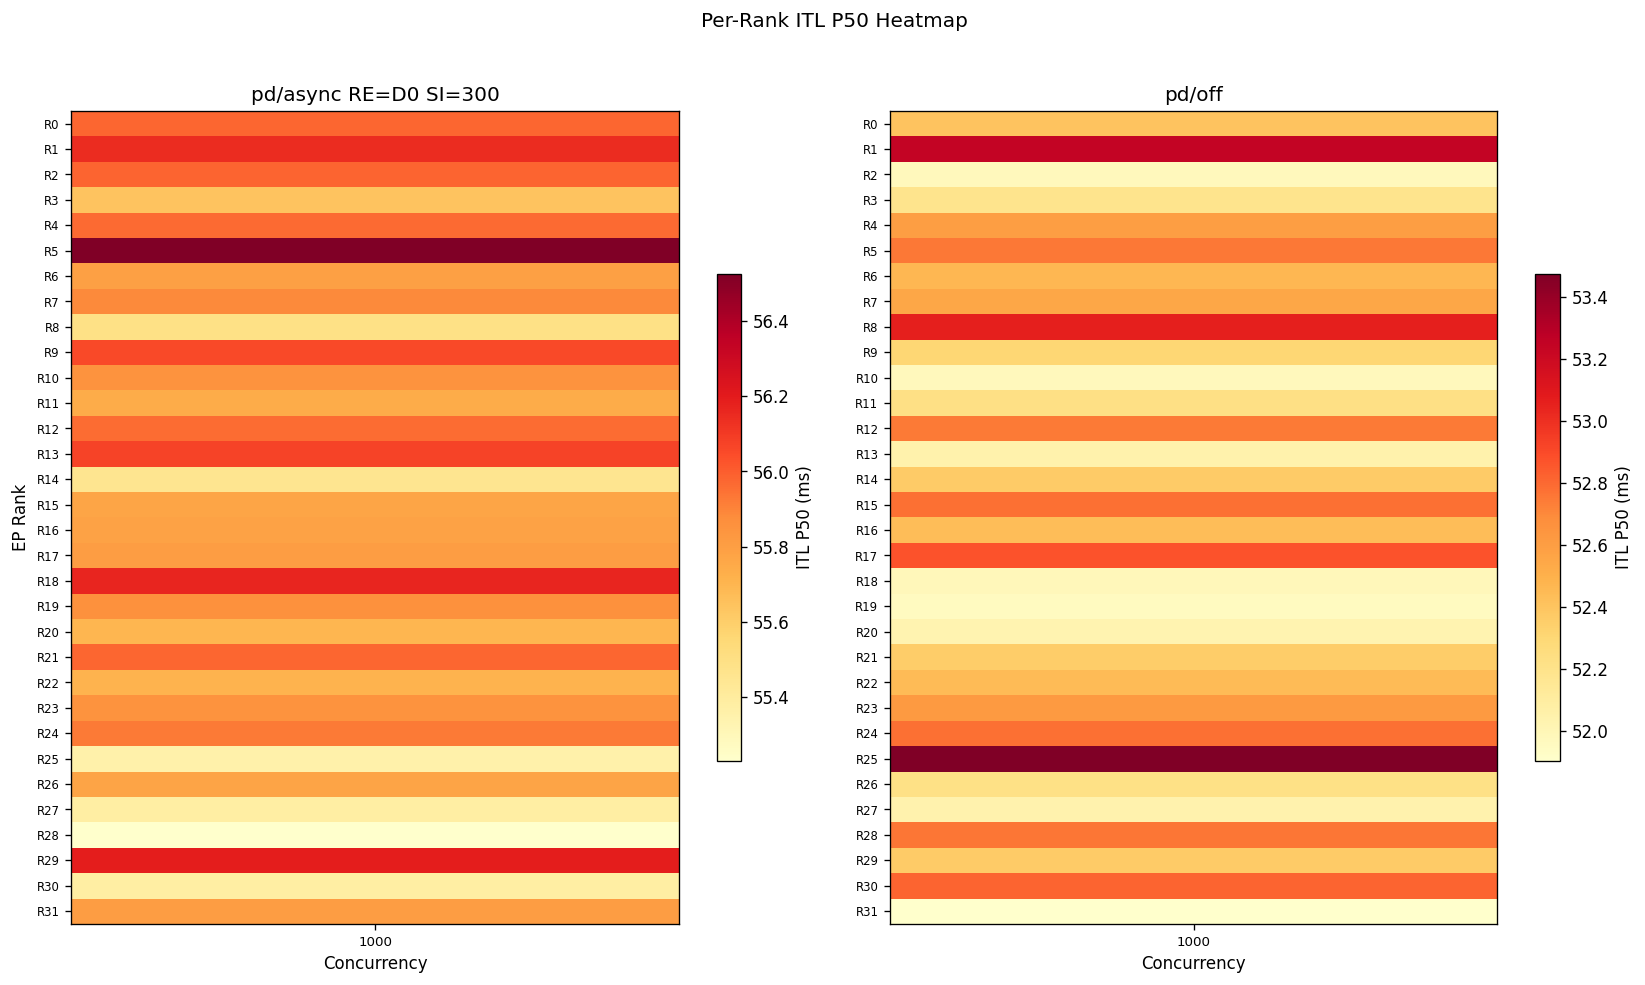

In [34]:
plot_per_rank_latency_heatmap(runs, metric="itl_p50", title="Per-Rank ITL P50 Heatmap", stage=1)
plt.show()

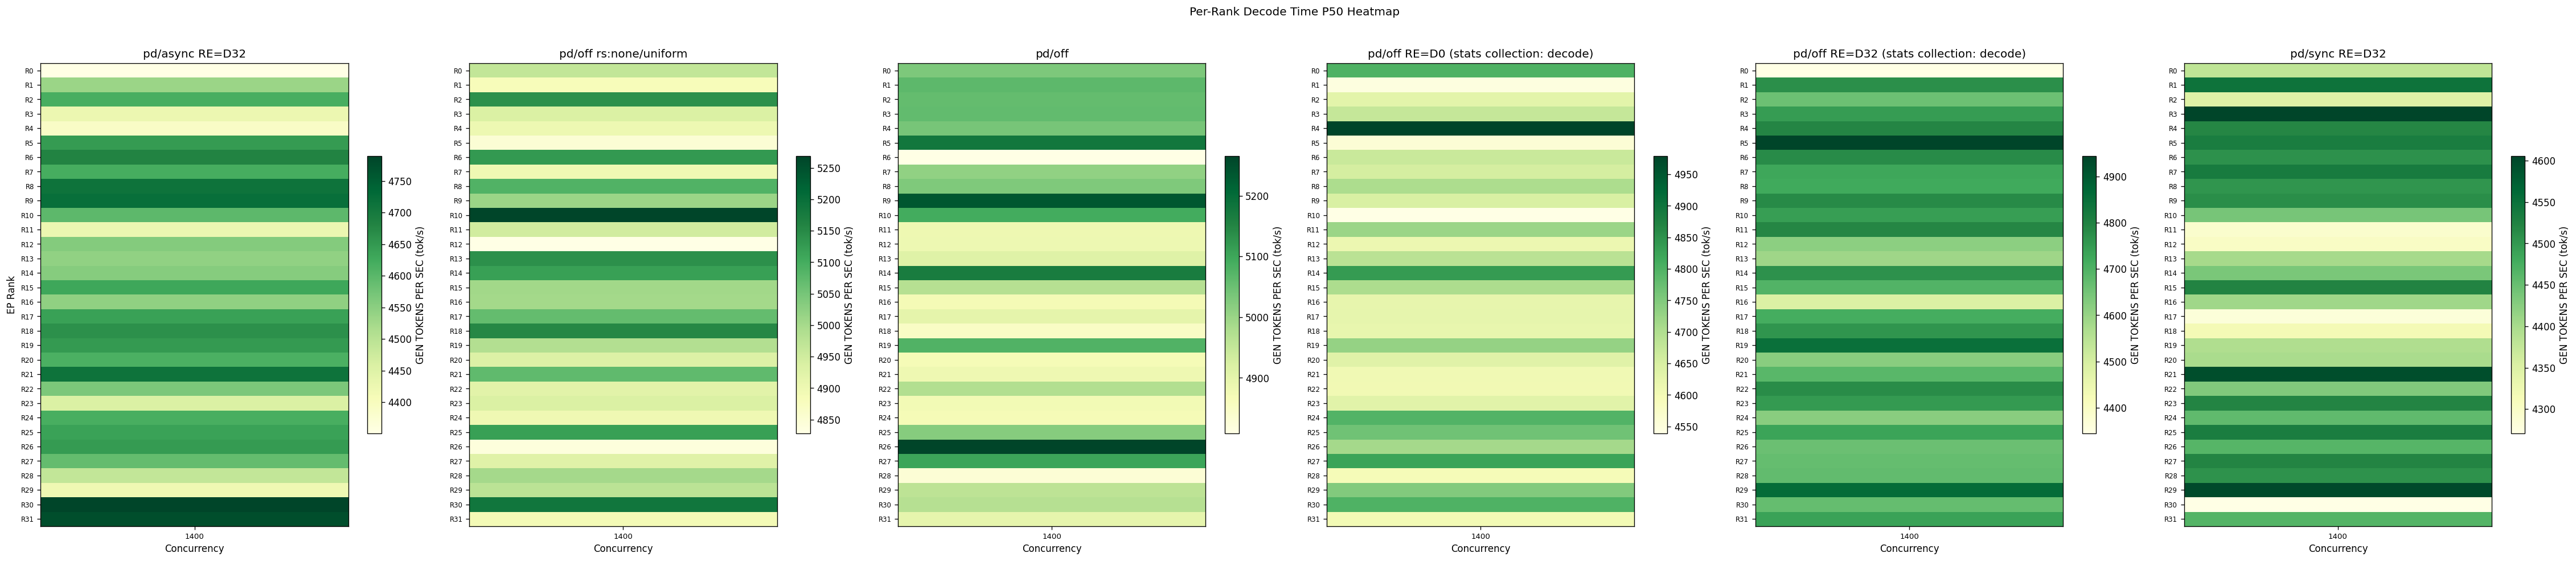

In [20]:
plot_per_rank_latency_heatmap(runs, metric="gen_tokens_per_sec", title="Per-Rank Decode Time P50 Heatmap", stage=2)
plt.show()

### 6b. Per-run deep dive

Select a single run to see its full expert load analysis (heatmap, rank balance, popularity, balancedness trend).

In [ ]:
# Pick a run to deep-dive (change the name here)
dive_run_name = run_names[0] if run_names else None

if dive_run_name and runs[dive_run_name].expert_loads:
    dive_run = runs[dive_run_name]
    for model_key, expert_data in dive_run.expert_loads.items():
        print(f"\n=== {dive_run_name} / {model_key} ===")
        print(f"  Model: {expert_data.model}")
        print(f"  EP width: {expert_data.world_size}")
        print(f"  Layers: {expert_data.num_layers}, Physical experts: {expert_data.num_physical}")
        print(f"  Redundant: {expert_data.num_redundant}, Per rank: {expert_data.experts_per_rank}")
        print(f"  Snapshots: {expert_data.num_snapshots}")
        plot_expert_load_all(expert_data, title_suffix=f"  [{dive_run_name}]")
        plt.show()
else:
    print(f"No expert load data for {dive_run_name}")

## 7. Phase 2: Parameter Sweep Analysis

Use these cells when comparing `num_redundant_experts` or `step_interval` sweeps. Adjust the `filter_*` calls to select the relevant runs.

In [ ]:
def filter_runs_by_prefix(runs: dict, prefix: str) -> dict:
    """Filter runs whose name starts with a prefix (e.g. 'nre-' for redundant expert sweep)."""
    return {k: v for k, v in runs.items() if k.startswith(prefix)}

# Example: num_redundant_experts sweep
nre_runs = filter_runs_by_prefix(runs, "nre-")
if nre_runs:
    print(f"num_redundant_experts sweep: {list(nre_runs.keys())}")
    plot_latency_comparison(nre_runs, title="Latency vs num_redundant_experts")
    plt.show()
    plot_throughput_comparison(nre_runs, title="Throughput vs num_redundant_experts")
    plt.show()
    plot_kv_cache_usage(nre_runs, title="KV Cache vs num_redundant_experts")
    plt.show()
    plot_balancedness_comparison(nre_runs, title="Balancedness vs num_redundant_experts")
    plt.show()
else:
    print("No nre-* runs found. Run Phase 2A sweep first.")

In [ ]:
# Example: step_interval sweep
si_runs = filter_runs_by_prefix(runs, "si-")
if si_runs:
    print(f"step_interval sweep: {list(si_runs.keys())}")
    plot_latency_comparison(si_runs, title="Latency vs step_interval")
    plt.show()
    plot_throughput_comparison(si_runs, title="Throughput vs step_interval")
    plt.show()
    plot_balancedness_comparison(si_runs, title="Balancedness vs step_interval")
    plt.show()
else:
    print("No si-* runs found. Run Phase 2B sweep first.")

In [ ]:
# Example: LWS scale sweep
lws_runs = filter_runs_by_prefix(runs, "lws-")
if lws_runs:
    print(f"LWS scale sweep: {list(lws_runs.keys())}")
    plot_latency_comparison(lws_runs, title="Latency vs LWS Size")
    plt.show()
    plot_throughput_comparison(lws_runs, title="Throughput vs LWS Size")
    plt.show()
    plot_balancedness_comparison(lws_runs, title="Balancedness vs LWS Size")
    plt.show()
else:
    print("No lws-* runs found. Run Phase 2C sweep first.")

## 8. Custom Queries

Scratch cells for ad-hoc analysis.

In [ ]:
# Example: compare two specific runs side by side
# run_a = load_run("pd-sync-eplb")
# run_b = load_run("pd-async-eplb")
# subset = {"sync": run_a, "async": run_b}
# plot_latency_comparison(subset)
# plot_throughput_comparison(subset)

In [ ]:
# Example: access raw Prometheus range data for custom plotting
# run = runs[run_names[0]]
# if run.prometheus:
#     df = run.prometheus.range_series("gen_tokens_per_sec_range")
#     if df is not None:
#         df.plot(x="time_min", y="value", title=f"{run.name} throughput")
#         plt.show()